# Car Crash Severity Prediction
## German University in Cairo — NETW 1013: Machine Learning - 55-3480
### EDA, Preprocessing, and Model Evaluation

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [49]:
train_df = pd.read_csv("/kaggle/input/competitions/car-crash-severity-prediction/car_crash_train.csv")
test_df  = pd.read_csv("/kaggle/input/competitions/car-crash-severity-prediction/car_crash_test.csv").drop(columns=['Severity'], errors='ignore')
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
train_df.head()

Train shape: (4000, 19)
Test shape:  (1000, 18)


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


---
## 1. Exploratory Data Analysis (EDA)
### 1.1 Basic Info

In [50]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float

In [51]:
train_df.describe()


,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,110.999750,89.979750,9.445500,48.698750,24.723000,0.101216,247.583500
std,52.227839,51.301514,5.718147,17.815972,14.211818,0.057820,143.478155
min,20.000000,0.000000,0.000000,18.000000,0.000000,0.000054,10.000000
25%,66.000000,45.000000,5.000000,34.000000,13.000000,0.050630,120.000000
50%,112.000000,89.500000,9.000000,49.000000,25.000000,0.101574,244.000000
75%,157.000000,134.000000,14.000000,64.000000,37.000000,0.151783,372.000000
max,199.000000,179.000000,19.000000,79.000000,49.000000,0.199936,499.000000


In [52]:
# Check for missing values
missing = train_df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values found.")

Missing values per column:
Distraction Level    2360
dtype: int64


### 1.2 Target Variable — Severity Distribution


Severity
Minor Injury     2756
Severe Injury    1038
Fatal             206
Name: count, dtype: int64

Severity
Minor Injury     68.90
Severe Injury    25.95
Fatal             5.15
Name: proportion, dtype: float64


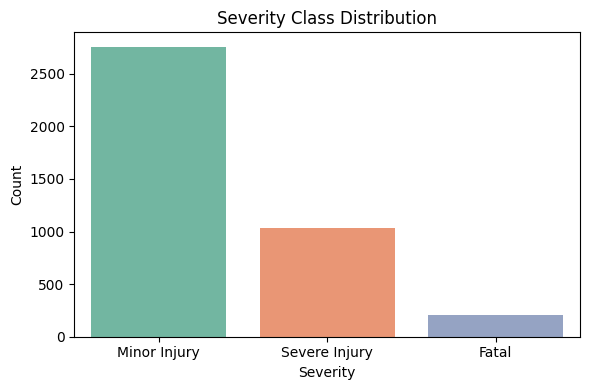

In [53]:
print(train_df['Severity'].value_counts())
print()
print(train_df['Severity'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='Severity', data=train_df, palette='Set2')
plt.title("Severity Class Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 1.3 Numerical Features — Distribution (Box Plots)

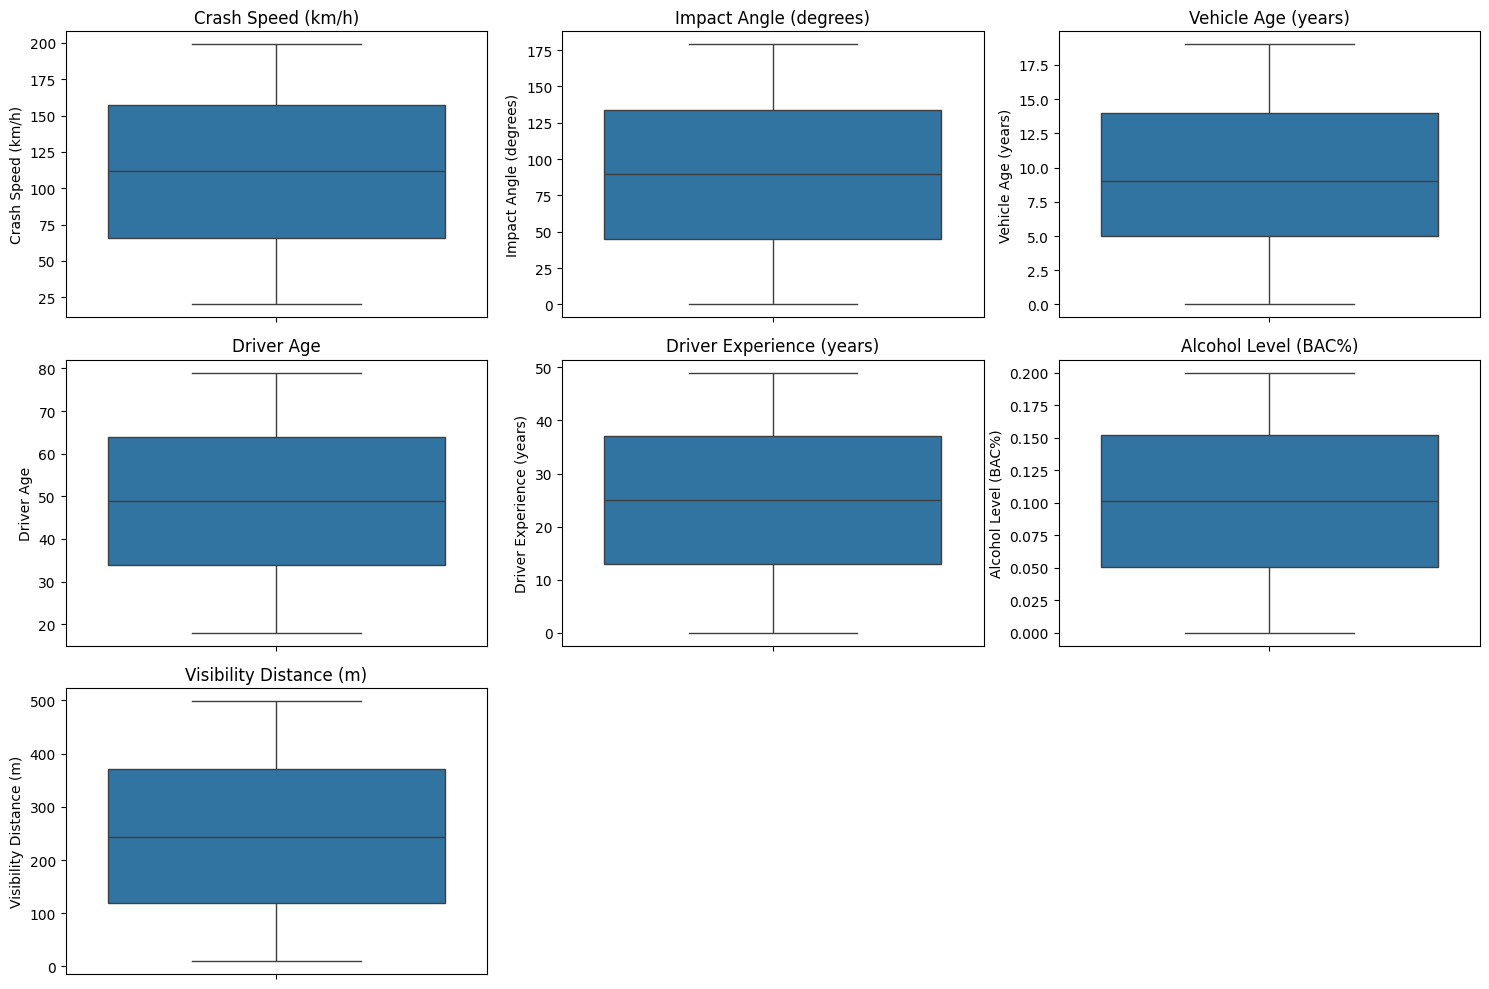

In [54]:
numerical_cols = [
    'Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
    'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)',
    'Visibility Distance (m)'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=train_df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### 1.4 Numerical Features vs. Severity
We plot each numerical feature against the target to see if any separation exists between severity classes.

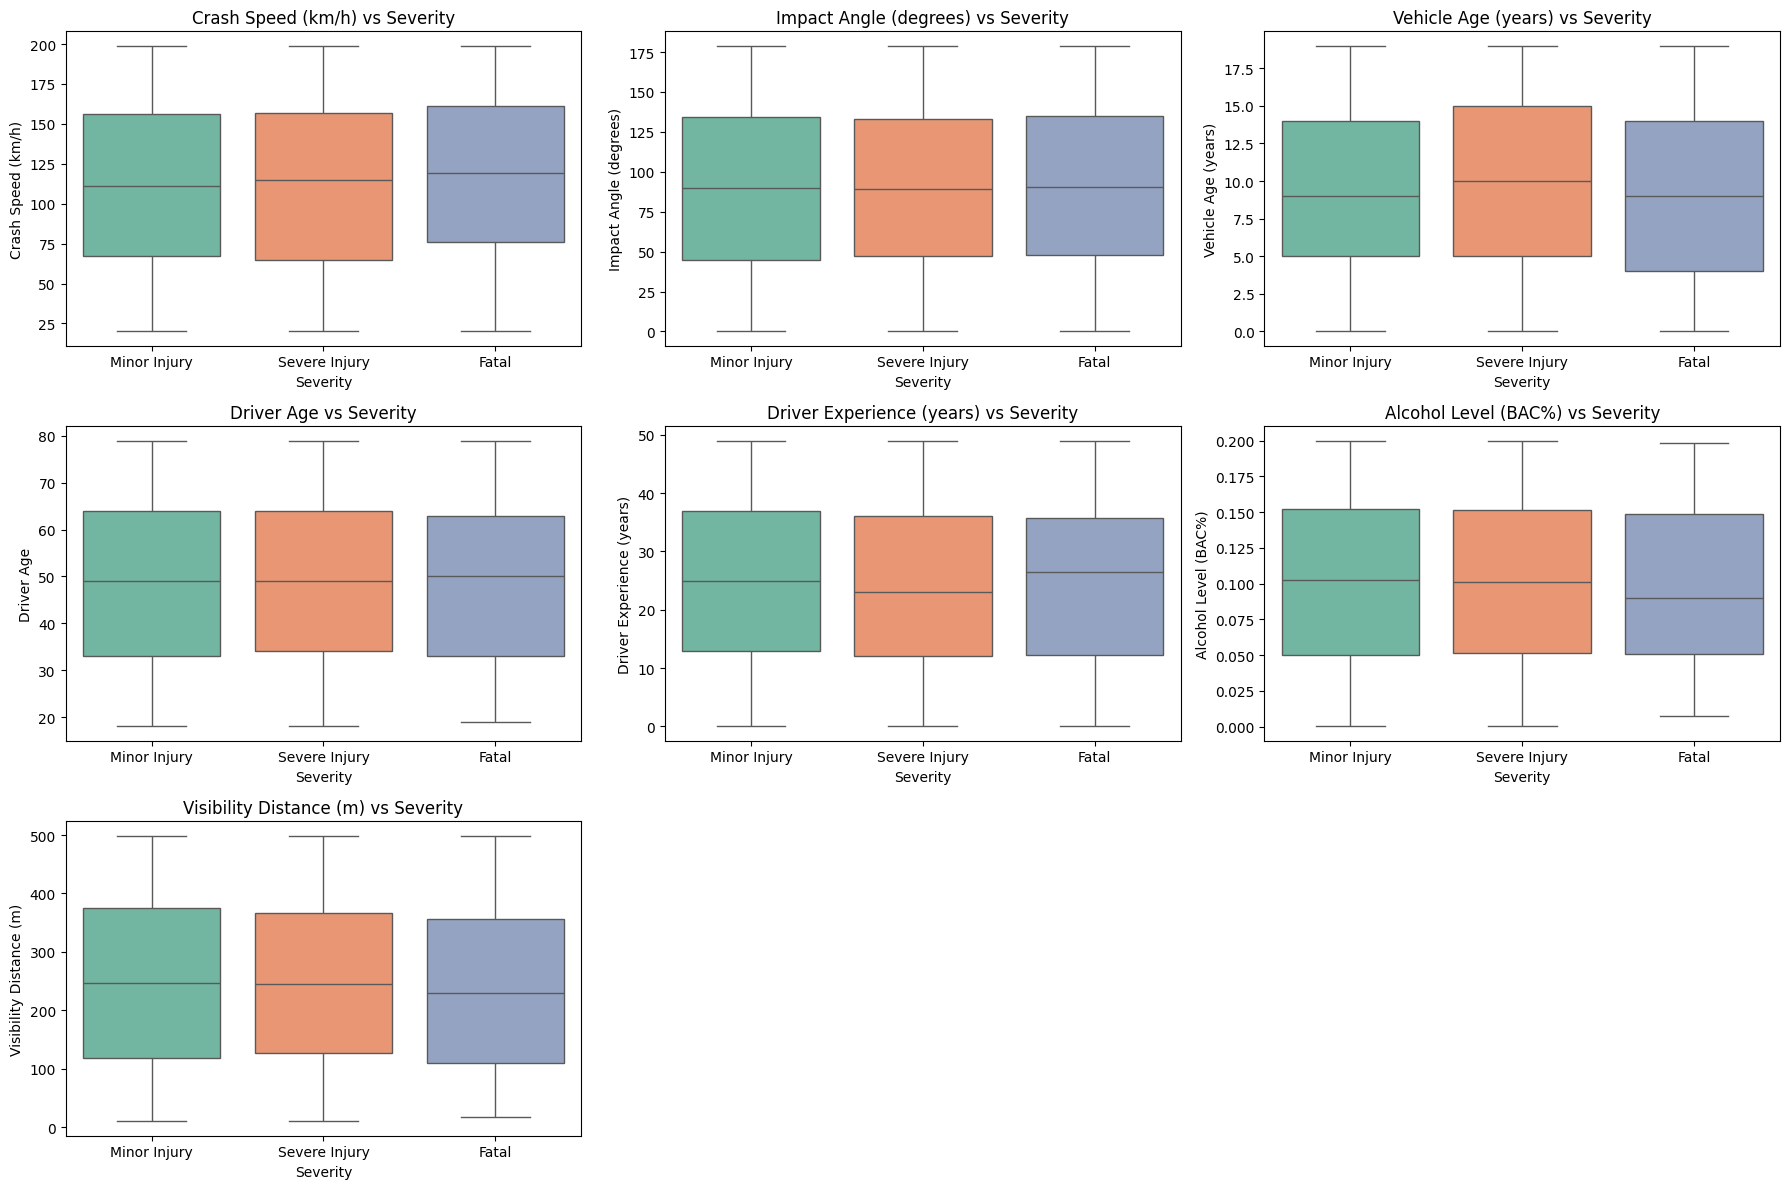

In [55]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Severity', y=col, data=train_df, palette='Set2')
    plt.title(f'{col} vs Severity')
    plt.tight_layout()
plt.show()

### 1.5 Correlation Matrix (Numerical Features)

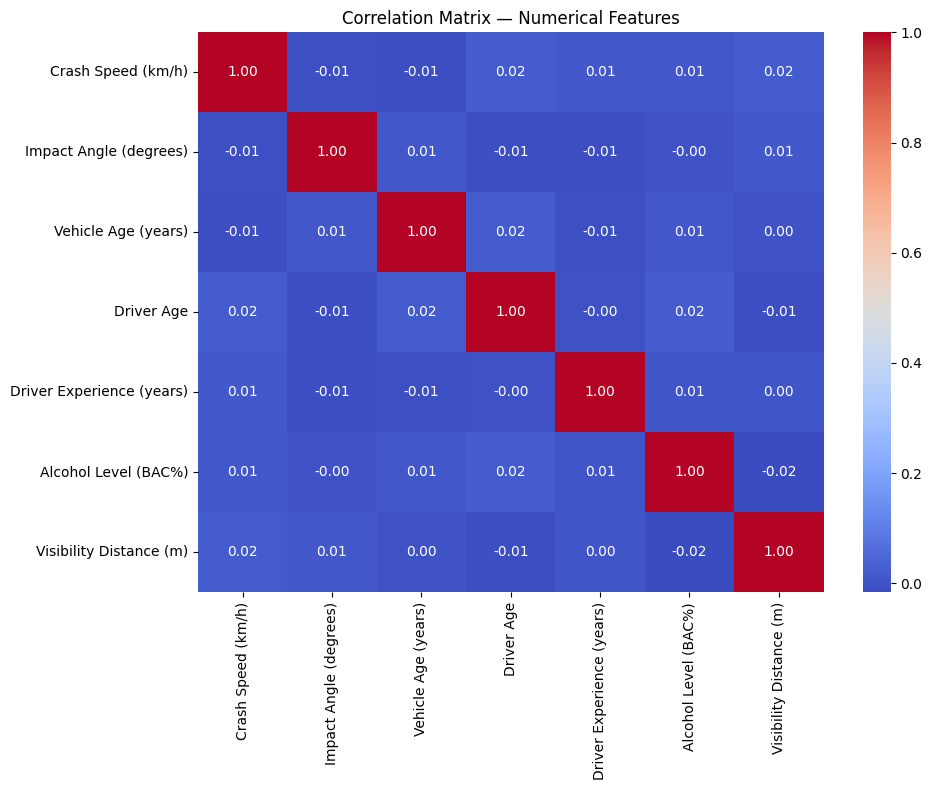

In [56]:
corr_matrix = train_df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()



All correlations are near zero, meaning the numerical features are
independent of each other. This is typical of synthetic datasets.
Feature importance will be assessed after model training.

### 1.6 Categorical Features — Distribution


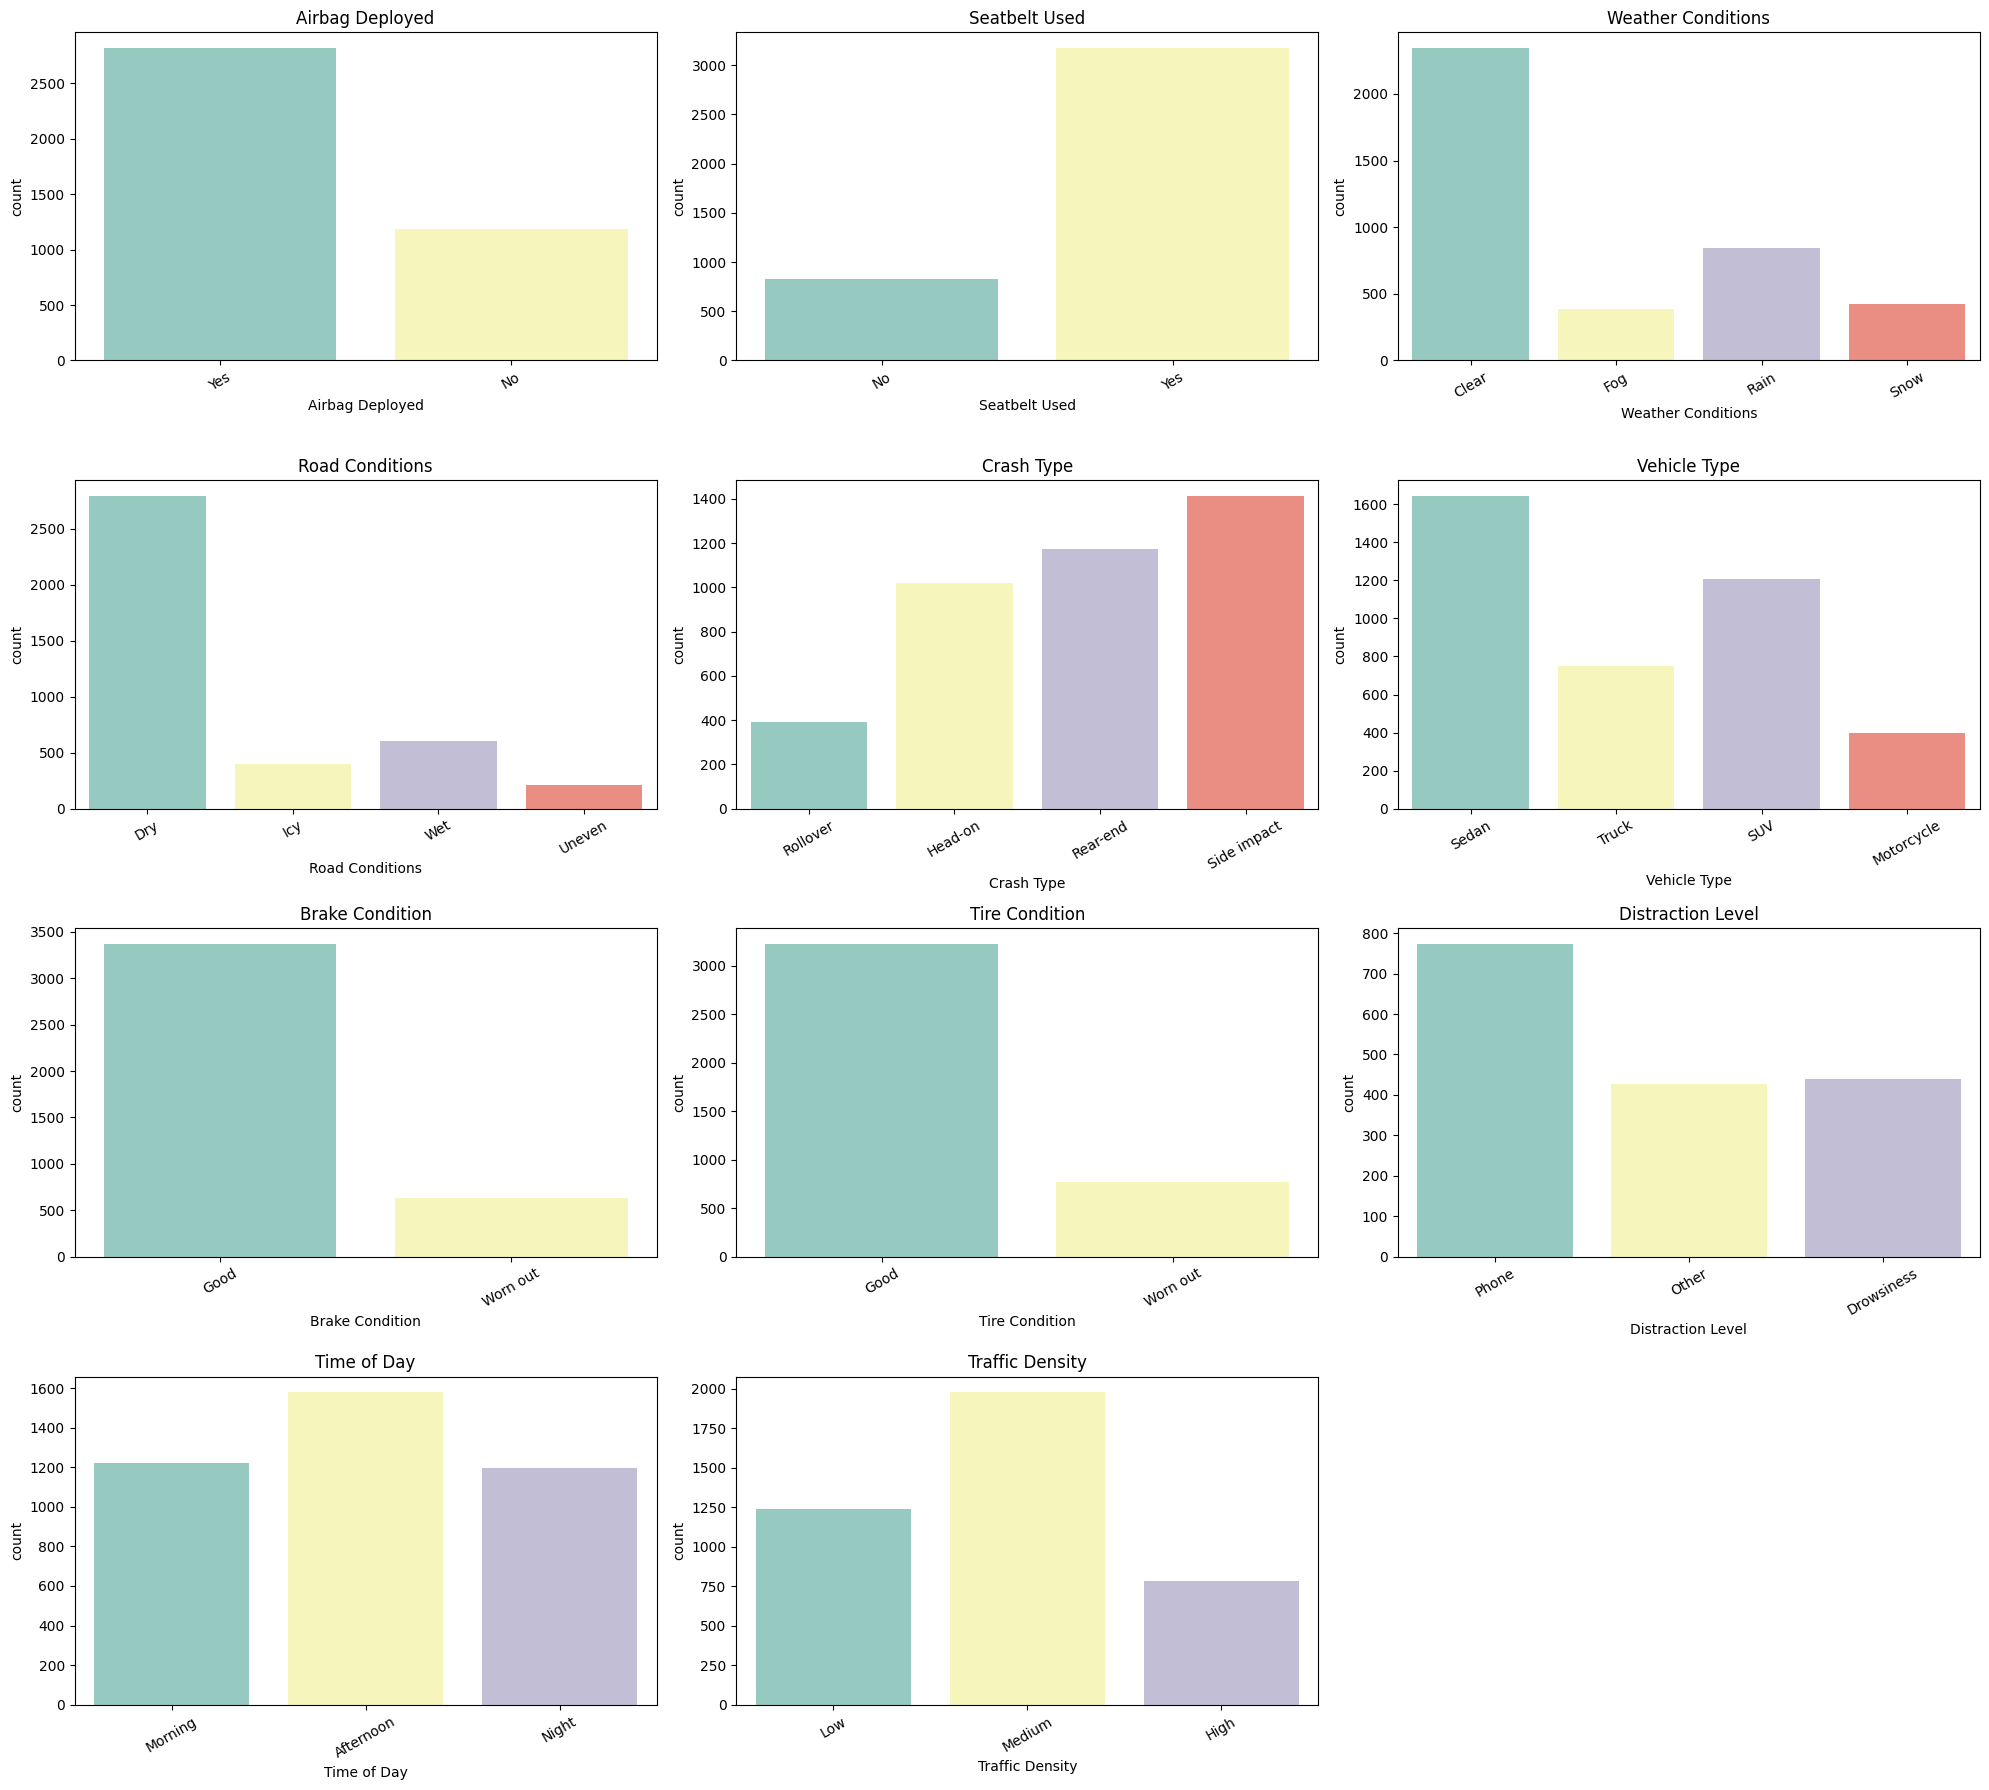

In [57]:
categorical_cols = [
    'Airbag Deployed', 'Seatbelt Used', 'Weather Conditions',
    'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition',
    'Tire Condition', 'Distraction Level', 'Time of Day', 'Traffic Density'
]

fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train_df, ax=axes[i], palette='Set3')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

# Hide the unused last subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### 1.7 Categorical Features vs. Severity

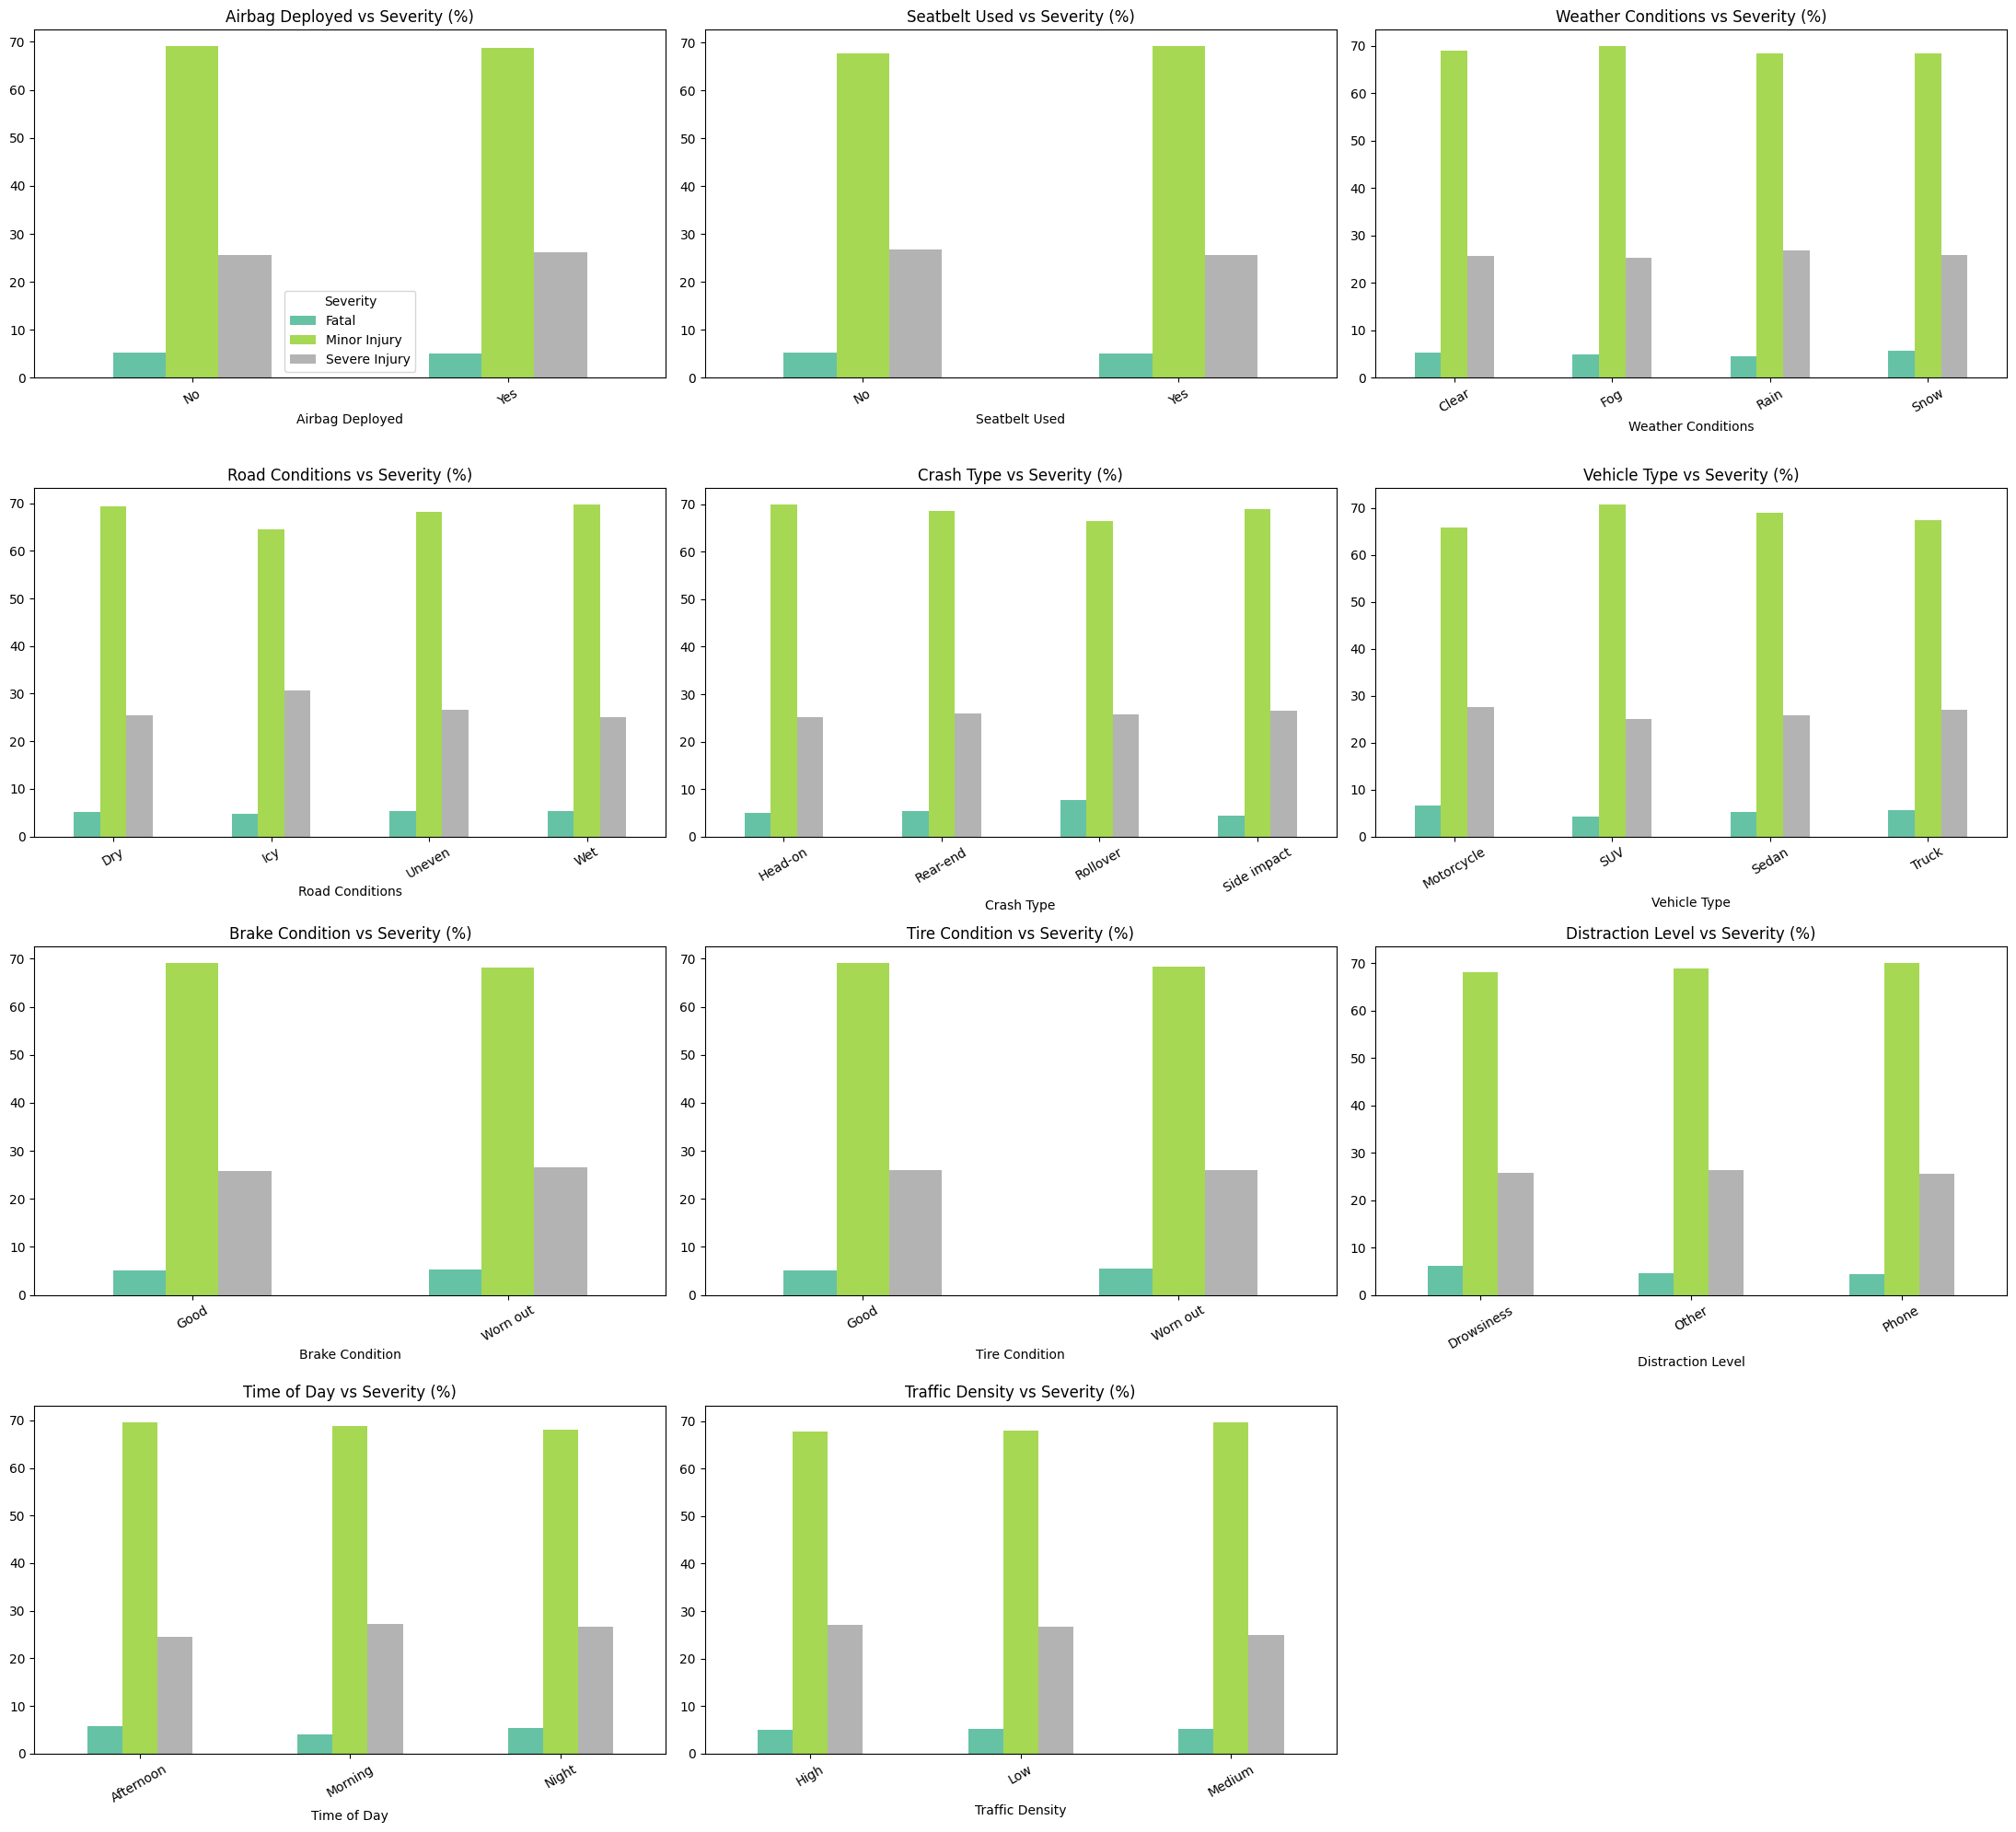

In [58]:
fig, axes = plt.subplots(4, 3, figsize=(22, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(train_df[col], train_df['Severity'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', legend=(i == 0))
    axes[i].set_title(f'{col} vs Severity (%)')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

---
## 2. Preprocessing
### 2.1 Encode Categorical Features
We use Label Encoding to convert categorical columns to integers.
The same encoder is applied to both train and test sets.

In [59]:
categorical_cols.remove('Distraction Level')
# Combine train and test for consistent encoding, then split back
combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
combined = combined.drop(columns=['Distraction Level'])

le = LabelEncoder()

for col in categorical_cols:
    combined[col] = le.fit_transform(combined[col].astype(str))

# Also encode target (train only)
target_le = LabelEncoder()
train_df['Severity_encoded'] = target_le.fit_transform(train_df['Severity'])
print("Severity classes:", target_le.classes_)

# Split back
train_encoded = combined.iloc[:len(train_df)].copy()
test_encoded  = combined.iloc[len(train_df):].copy()

train_encoded['Severity_encoded'] = train_df['Severity_encoded'].values

print("Encoding complete.")
train_encoded.head()

Severity classes: ['Fatal' 'Minor Injury' 'Severe Injury']
Encoding complete.


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Time of Day,Traffic Density,Visibility Distance (m),Severity,Severity_encoded
0,182,69,1,0,0,0,2,2,5,0,0,23,11,0.025314,1,1,213,Minor Injury,1
1,192,73,1,0,0,0,0,3,3,0,0,29,27,0.002372,1,2,426,Minor Injury,1
2,114,77,0,1,0,0,0,2,16,0,1,73,45,0.000483,1,2,175,Minor Injury,1
3,93,14,0,1,0,0,1,3,14,1,1,27,18,0.176578,0,2,82,Minor Injury,1
4,170,96,0,1,0,0,3,1,15,0,0,70,27,0.065696,1,2,96,Severe Injury,2


Distraction Level was dropped for two reasons: (1) 59% of values are missing with no reliable imputation strategy since missingness indicates the field was not recorded, and (2) EDA shows the severity distribution is nearly identical across all recorded distraction categories (Drowsiness, Other, Phone), indicating the feature carries no meaningful predictive signal.


### 2.2 Define Features and Target

In [60]:
feature_cols = numerical_cols + categorical_cols

X = train_encoded[feature_cols]
y = train_encoded['Severity_encoded']

X_test_final = test_encoded[feature_cols]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Test shape:", X_test_final.shape)

Feature matrix shape: (4000, 17)
Target shape: (4000,)
Test shape: (1000, 17)


### 2.3 Train/Validation Split
We use an 80/20 split. Stratification ensures each severity class is proportionally represented.

In [61]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:  ", X_train.shape)
print("Validation set size:", X_val.shape)

Training set size:   (3200, 17)
Validation set size: (800, 17)


### 2.4 Scale Numerical Features
Scaling is important for distance-based models (KNN, Logistic Regression).
Tree-based models don't require it but we apply it uniformly for consistency.

In [62]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test_final.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val_scaled[numerical_cols]   = scaler.transform(X_val[numerical_cols])
X_test_scaled[numerical_cols]  = scaler.transform(X_test_final[numerical_cols])

print("Scaling complete.")

Scaling complete.


---
## 3. Model Training and Evaluation

We define a helper function to evaluate every model consistently using:
- **Accuracy** — overall correct predictions
- **Macro F1-Score** — balances performance across all severity classes
- **Confusion Matrix** — per-class breakdown
- **Classification Report** — precision, recall, F1 per class

In [63]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    
    acc = accuracy_score(y_v, preds)
    f1  = f1_score(y_v, preds, average='macro')
    
    results[name] = {'Accuracy': round(acc, 4), 'Macro F1': round(f1, 4)}
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro F1 : {f1:.4f}")
    print()
    print(classification_report(y_v, preds, target_names=target_le.classes_))
    
    cm = confusion_matrix(y_v, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_le.classes_)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()
    
    return model

### 3.1 K-Nearest Neighbors (KNN)
KNN classifies each sample based on the majority class among its K nearest neighbors.
It is a non-parametric, instance-based learner — sensitive to feature scaling.


  K-Nearest Neighbors
  Accuracy : 0.6362
  Macro F1 : 0.3175

               precision    recall  f1-score   support

        Fatal       0.10      0.02      0.04        41
 Minor Injury       0.69      0.89      0.78       551
Severe Injury       0.24      0.10      0.14       208

     accuracy                           0.64       800
    macro avg       0.34      0.34      0.32       800
 weighted avg       0.54      0.64      0.57       800



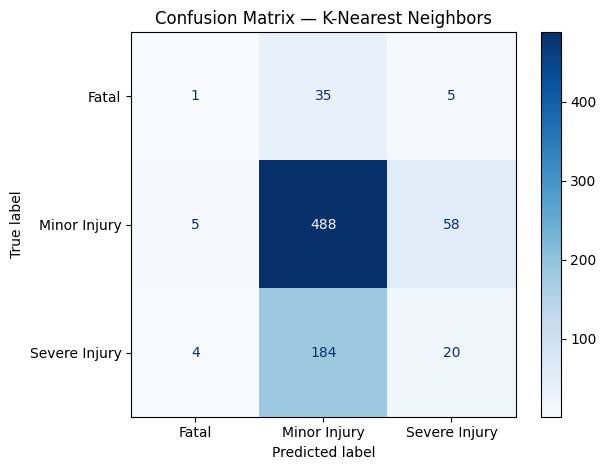

In [64]:
knn = evaluate_model(
    "K-Nearest Neighbors",
    KNeighborsClassifier(n_neighbors=5),
    X_train_scaled, y_train,
    X_val_scaled, y_val
)

### 3.2 Decision Tree
Decision Trees split data recursively on the most informative feature.
They are interpretable but can overfit if not pruned.


  Decision Tree
  Accuracy : 0.6262
  Macro F1 : 0.3033

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.68      0.87      0.76       551
Severe Injury       0.23      0.11      0.15       208

     accuracy                           0.63       800
    macro avg       0.30      0.33      0.30       800
 weighted avg       0.53      0.63      0.56       800



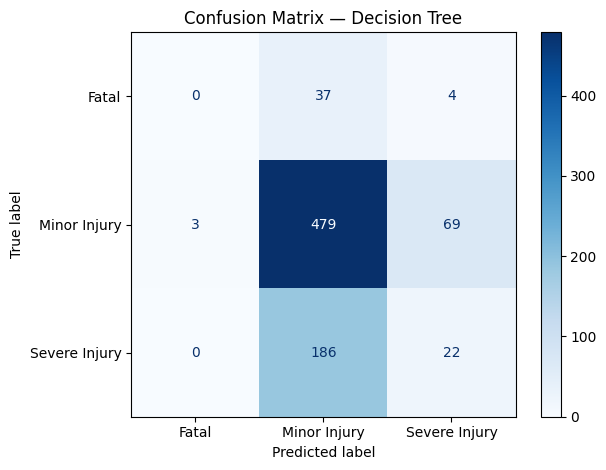

In [65]:
dt = evaluate_model(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42, max_depth=10),
    X_train_scaled, y_train,
    X_val_scaled, y_val
)

### 3.3 Random Forest
Random Forest builds many decision trees on random subsets of data and features,
then averages their predictions. This reduces overfitting and improves generalization.


  Random Forest
  Accuracy : 0.6863
  Macro F1 : 0.2713

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.81       551
Severe Injury       0.00      0.00      0.00       208

     accuracy                           0.69       800
    macro avg       0.23      0.33      0.27       800
 weighted avg       0.47      0.69      0.56       800



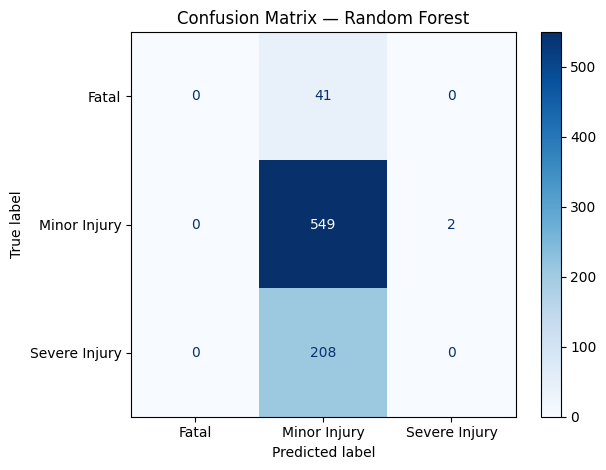

In [66]:
rf = evaluate_model(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_scaled, y_train,
    X_val_scaled, y_val
)

### 3.4 Logistic Regression
Logistic Regression models the probability of each class using a linear decision boundary.
It works best when classes are linearly separable and features are well-scaled.


  Logistic Regression
  Accuracy : 0.6887
  Macro F1 : 0.2719

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.82       551
Severe Injury       0.00      0.00      0.00       208

     accuracy                           0.69       800
    macro avg       0.23      0.33      0.27       800
 weighted avg       0.47      0.69      0.56       800



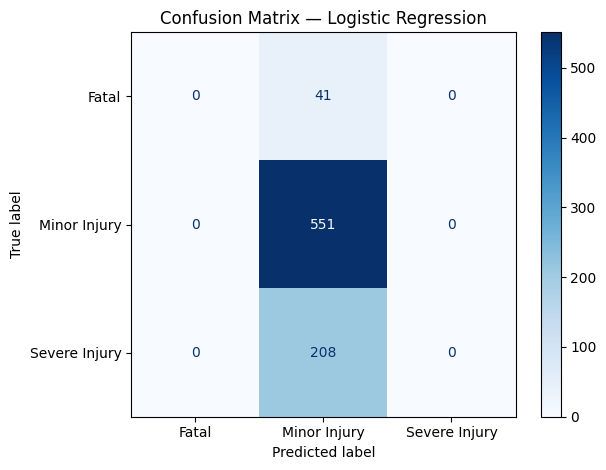

In [67]:
lr = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled, y_train,
    X_val_scaled, y_val
)

### 3.5 Naïve Bayes
Naïve Bayes assumes all features are independent given the class label.
Despite this strong assumption, it often performs surprisingly well in practice.


  Naïve Bayes
  Accuracy : 0.6887
  Macro F1 : 0.2719

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.82       551
Severe Injury       0.00      0.00      0.00       208

     accuracy                           0.69       800
    macro avg       0.23      0.33      0.27       800
 weighted avg       0.47      0.69      0.56       800



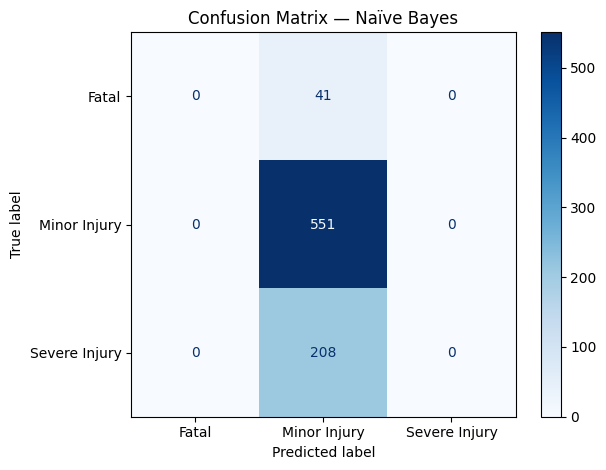

In [68]:
nb = evaluate_model(
    "Naïve Bayes",
    GaussianNB(),
    X_train_scaled, y_train,
    X_val_scaled, y_val
)

### 3.6 XGBoost 
XGBoost is a gradient boosting framework that builds trees sequentially,
each correcting the errors of the previous. It often achieves state-of-the-art results
on structured/tabular data.


  XGBoost
  Accuracy : 0.6675
  Macro F1 : 0.2912

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      0.95      0.80       551
Severe Injury       0.24      0.04      0.07       208

     accuracy                           0.67       800
    macro avg       0.31      0.33      0.29       800
 weighted avg       0.54      0.67      0.57       800



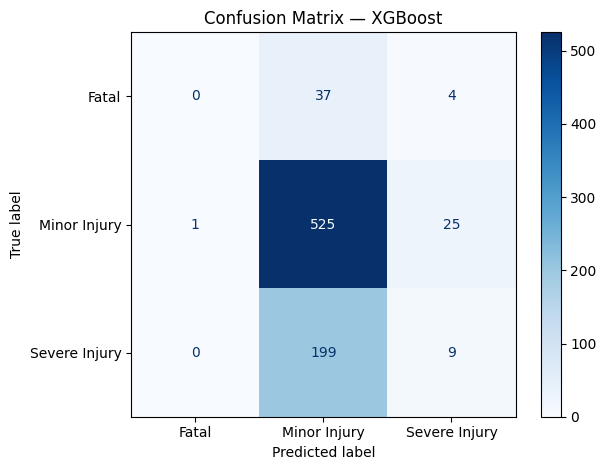

In [69]:
xgb_model = evaluate_model(
    "XGBoost",
    xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                      use_label_encoder=False, eval_metric='mlogloss',
                      random_state=42, n_jobs=-1),
    X_train_scaled, y_train,
    X_val_scaled, y_val
)

---
## 4. Model Comparison


                     Accuracy  Macro F1
K-Nearest Neighbors    0.6362    0.3175
Decision Tree          0.6262    0.3033
XGBoost                0.6675    0.2912
Logistic Regression    0.6887    0.2719
Naïve Bayes            0.6887    0.2719
Random Forest          0.6863    0.2713


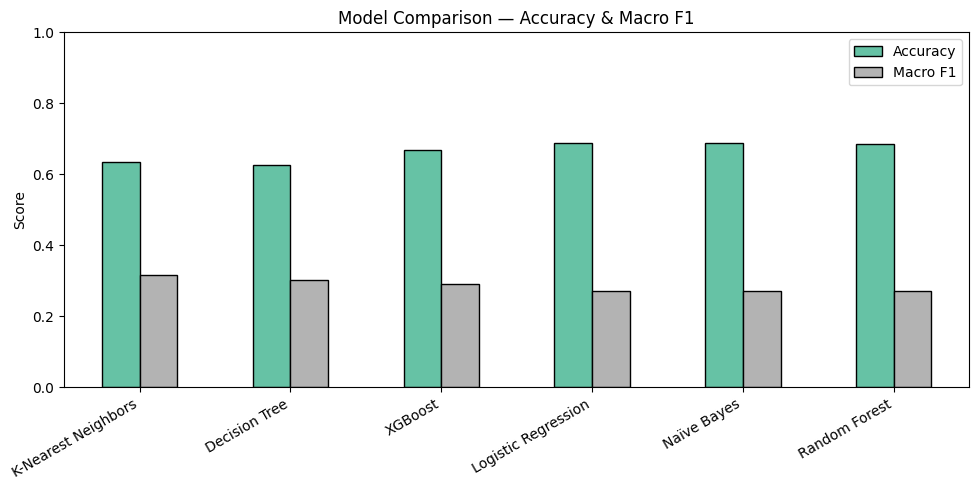


Best model: K-Nearest Neighbors with Macro F1 = 0.3175


In [70]:
results_df = pd.DataFrame(results).T.sort_values('Macro F1', ascending=False)
print(results_df)

results_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title("Model Comparison — Accuracy & Macro F1")
plt.ylabel("Score")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

best_model_name = results_df.index[0]
print(f"\nBest model: {best_model_name} with Macro F1 = {results_df.iloc[0]['Macro F1']}")

---
## 5. Feature Importance (Random Forest)
Random Forest provides feature importances showing which variables contributed most to predictions.

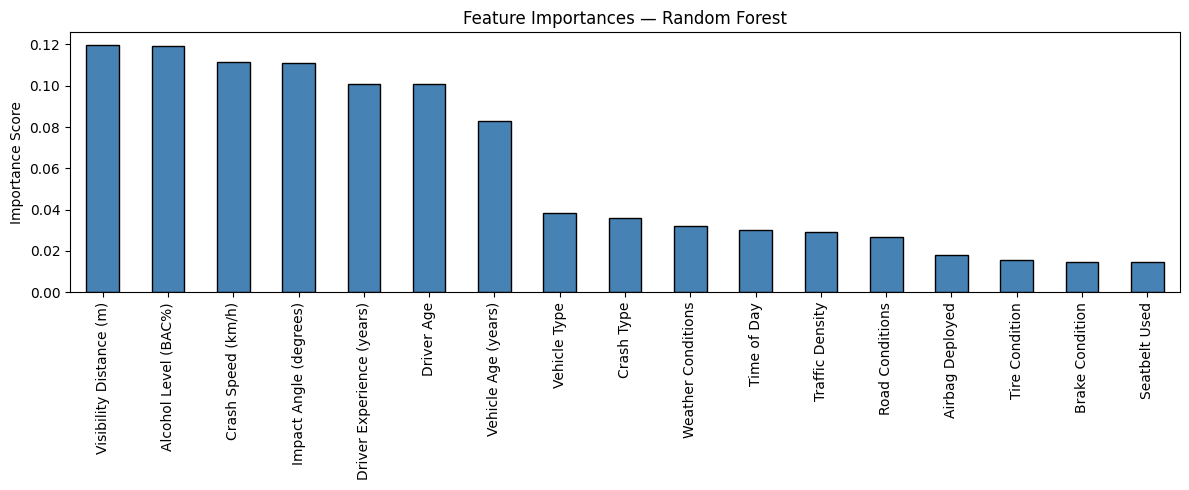

In [71]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Feature Importances — Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

---
## 6. Final Submission
We retrain the best-performing model on the **full training dataset** (not just 80%),
then generate predictions on the test set for Kaggle submission.

In [72]:
## 6. Retrain Best Model on Full Training Data & Generate Submission

# Map model name to model object
model_map = {
    "K-Nearest Neighbors" : KNeighborsClassifier(n_neighbors=5),
    "Decision Tree"        : DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest"        : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Logistic Regression"  : LogisticRegression(max_iter=1000, random_state=42),
    "Naïve Bayes"          : GaussianNB(),
    "XGBoost"              : xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                                use_label_encoder=False, eval_metric='mlogloss',
                                                random_state=42, n_jobs=-1),
}

# Refit scaler on full training data
full_scaler = StandardScaler()
X_full_scaled = X.copy()
X_full_scaled[numerical_cols] = full_scaler.fit_transform(X[numerical_cols])

# Scale test set with the same scaler
X_test_final_scaled = X_test_final.copy()
X_test_final_scaled[numerical_cols] = full_scaler.transform(X_test_final[numerical_cols])

# Retrain best model on full training data
final_model = model_map[best_model_name]
final_model.fit(X_full_scaled, y)
print(f"Retrained '{best_model_name}' on full training data ({X_full_scaled.shape[0]} samples).")

# Predict on train and test separately
train_preds_encoded = final_model.predict(X_full_scaled)
test_preds_encoded  = final_model.predict(X_test_final_scaled)

train_preds = target_le.inverse_transform(train_preds_encoded)
test_preds  = target_le.inverse_transform(test_preds_encoded)

# Load sample submission for correct ID order and column name
sample_sub = pd.read_csv("/kaggle/input/competitions/car-crash-severity-prediction/sample_submission.csv")

# Sanity check sizes
print(f"\nSample submission shape : {sample_sub.shape}")   # (5000, 2)
print(f"Train predictions       : {len(train_preds)}")    # 4000
print(f"Test predictions        : {len(test_preds)}")     # 1000

# Combine train + test predictions positionally (train rows first, then test rows)
all_preds = list(train_preds) + list(test_preds)

submission = pd.DataFrame({
    'ID'                : sample_sub['ID'],
    'Predicted_Severity': all_preds
})

# Sanity checks
print(f"\nMissing predictions: {submission['Predicted_Severity'].isnull().sum()}")  # must be 0
print(f"Submission shape:    {submission.shape}")                                   # must be (5000, 2)
print("\nPrediction distribution:")
print(submission['Predicted_Severity'].value_counts())

submission.to_csv("submission.csv", index=False)
print("\nsubmission.csv saved.")
submission.head(10)

Retrained 'K-Nearest Neighbors' on full training data (4000 samples).

Sample submission shape : (5000, 2)
Train predictions       : 4000
Test predictions        : 1000

Missing predictions: 0
Submission shape:    (5000, 2)

Prediction distribution:
Predicted_Severity
Minor Injury     4400
Severe Injury     525
Fatal              75
Name: count, dtype: int64

submission.csv saved.


,ID,Predicted_Severity
0,5ca30a05-b855-4cf3-915f-a92a6be7c010,Minor Injury
1,cc90ec30-fbb8-4f72-8814-8df3b82ea995,Minor Injury
2,a35b1df3-d476-4e21-b4be-54356572decb,Minor Injury
3,3f6e8e90-e5e7-4f49-93b2-64c1970839ce,Minor Injury
4,68829fcb-2211-40b4-a9a0-d06a8c6c970c,Minor Injury
5,59fea189-62d6-4820-a916-e501ecafb0b8,Minor Injury
6,c7d4ae29-e1d5-4ac8-8f1d-02f6dacafaaf,Minor Injury
7,51ae5acd-b2f6-47dd-814b-6ff04d726aa0,Minor Injury
8,7d5c9773-c60f-44ed-93ee-1bdbe0835ae0,Minor Injury
9,8e571fc4-f58b-4139-ba51-00429a2f3d72,Minor Injury



# **Model Interpretation**

Dataset is severely skewed: 
Minor Injury: 68.9% (2,756 samples)
Severe Injury: 25.95% (1,038 samples)
Fatal: 5.15% (206 samples)

This is the lens through which every model result must be read. A model that predicts "Minor Injury" for everything would score ~69% accuracy — which is exactly what many of your models do.

# Model-by-Model Interpretation

**K-Nearest Neighbors — Best by Macro F1 (0.3175, Acc: 63.62%)**

KNN is the winner because it is the only model that meaningfully attempts to predict minority classes. It achieves 2% recall on Fatal and 10% recall on Severe Injury — small numbers, but enough to edge out all other models that completely ignore those classes. Its lower raw accuracy compared to Random Forest or Logistic Regression is not a weakness — it reflects the model actually engaging with harder classes rather than defaulting to the majority. Macro F1 correctly rewards this behavior.


**Decision Tree — Macro F1: 0.3033, Acc: 62.62%**

Similar behavior to KNN but slightly worse across all metrics. Fatal is completely missed (F1 = 0.00, 0% recall), while Severe Injury achieves 11% recall and F1 of 0.15. The max_depth=10 cap prevents extreme overfitting but is not enough to overcome the class imbalance. Despite missing Fatal entirely, it remains the second-best model by Macro F1 because it still captures some Severe Injury cases.


**Random Forest — Highest Accuracy (68.63%) but very low Macro F1 (0.2713)**

Random Forest achieves the highest raw accuracy but collapses entirely: 0% recall on both Fatal and Severe Injury — it predicts "Minor Injury" for every single sample. This is the textbook example of why accuracy is a misleading metric on imbalanced data. A trivial classifier that always outputs "Minor Injury" would also score ~69%. Despite being a powerful ensemble method, Random Forest gravitates to the majority class without class weighting, making its high accuracy meaningless for this task.

**Logistic Regression — Macro F1: 0.2719, Acc: 68.87%**

Same collapse as Random Forest — 0% recall on both Fatal and Severe Injury. This is expected: the classes are not linearly separable, so the linear decision boundary cannot distinguish minority classes and simply assigns everything to the dominant class. Adding class_weight='balanced' would force it to penalize minority class errors more heavily, which would likely improve Macro F1 significantly.

**Naïve Bayes — Macro F1: 0.2719, Acc: 68.87%**

The output is numerically identical to Logistic Regression — same accuracy and Macro F1 to 4 decimal places, same 0% recall on Fatal and Severe Injury. Both models collapsed to the same degenerate solution of predicting only Minor Injury. Despite Naïve Bayes operating on completely different assumptions (feature independence and probabilistic inference), the class imbalance dominates and drives both models to the same failure mode.

**XGBoost — Macro F1: 0.2912, Acc: 66.75%**

XGBoost performs better than the fully collapsed models but falls short of KNN and Decision Tree. It manages 4% recall on Severe Injury (F1 = 0.07) but completely misses Fatal (0% recall). Given that XGBoost is typically the strongest model on tabular data, this underperformance is not a model failure — it is a data problem. The severe class imbalance (5.15% Fatal) overwhelms the boosting process without explicit imbalance handling such as scale_pos_weight or SMOTE. With those adjustments, XGBoost would likely become the best-performing model.